### Abalone - Regression

In [1]:
import os
import time
 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import Image

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

import keras
from keras_tuner import HyperParameters, Objective
from keras_tuner.tuners import RandomSearch

In [2]:
# Zadanie 1
# 1)
abalone_df = pd.read_csv("abalone(in).csv")

# 2)
abalone_df.info()
abalone_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   str    
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 293.8 KB


,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [3]:
# 3) EDA - Abalone with height 0 are broken data rows, as well as there are rows where value in column 'whole weight' is actaully smaller than the sum of the remaining weight columns.
zero_height_rows = abalone_df["Height"] == 0
incorrect_weight_rows = (abalone_df["Shucked weight"] + abalone_df["Viscera weight"] + abalone_df["Shell weight"]) > abalone_df["Whole weight"]

# Drop broken data records from original df where incorrect weight mask or zero height mask resolves to True
abalone_df = abalone_df.drop(abalone_df.loc[incorrect_weight_rows | zero_height_rows].index)

# 4) 
print(abalone_df["Sex"].unique())
print(abalone_df["Sex"].value_counts())

<StringArray>
['M', 'F', 'I']
Length: 3, dtype: str
Sex
M    1487
F    1279
I    1255
Name: count, dtype: int64


<Axes: xlabel='Rings', ylabel='Count'>

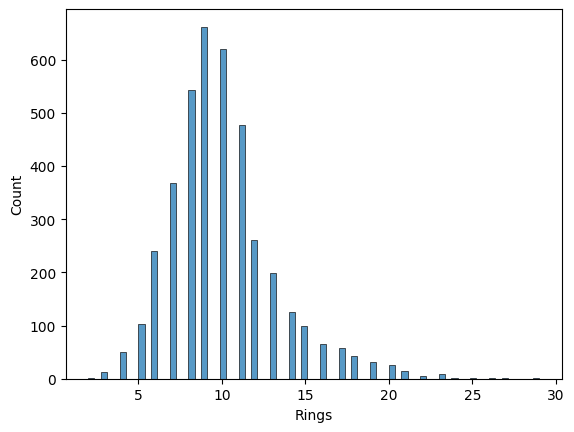

In [4]:
# Zadanie 2

# 1) 
sns.histplot(abalone_df["Rings"])

/Users/jancewicz/Repos/PJATK/PJATK---Artificial-Intelligence-Postgraduate-Studies-/keras/venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/jancewicz/Repos/PJATK/PJATK---Artificial-Intelligence-Postgraduate-Studies-/keras/venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/jancewicz/Repos/PJATK/PJATK---Artificial-Intelligence-Postgraduate-Studies-/keras/venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/jancewicz/Repos/PJATK/PJATK---Artificial-Intelligence-Postgraduate-Studies-/keras/venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/jancewicz/Repos/PJATK/PJATK---Artificial

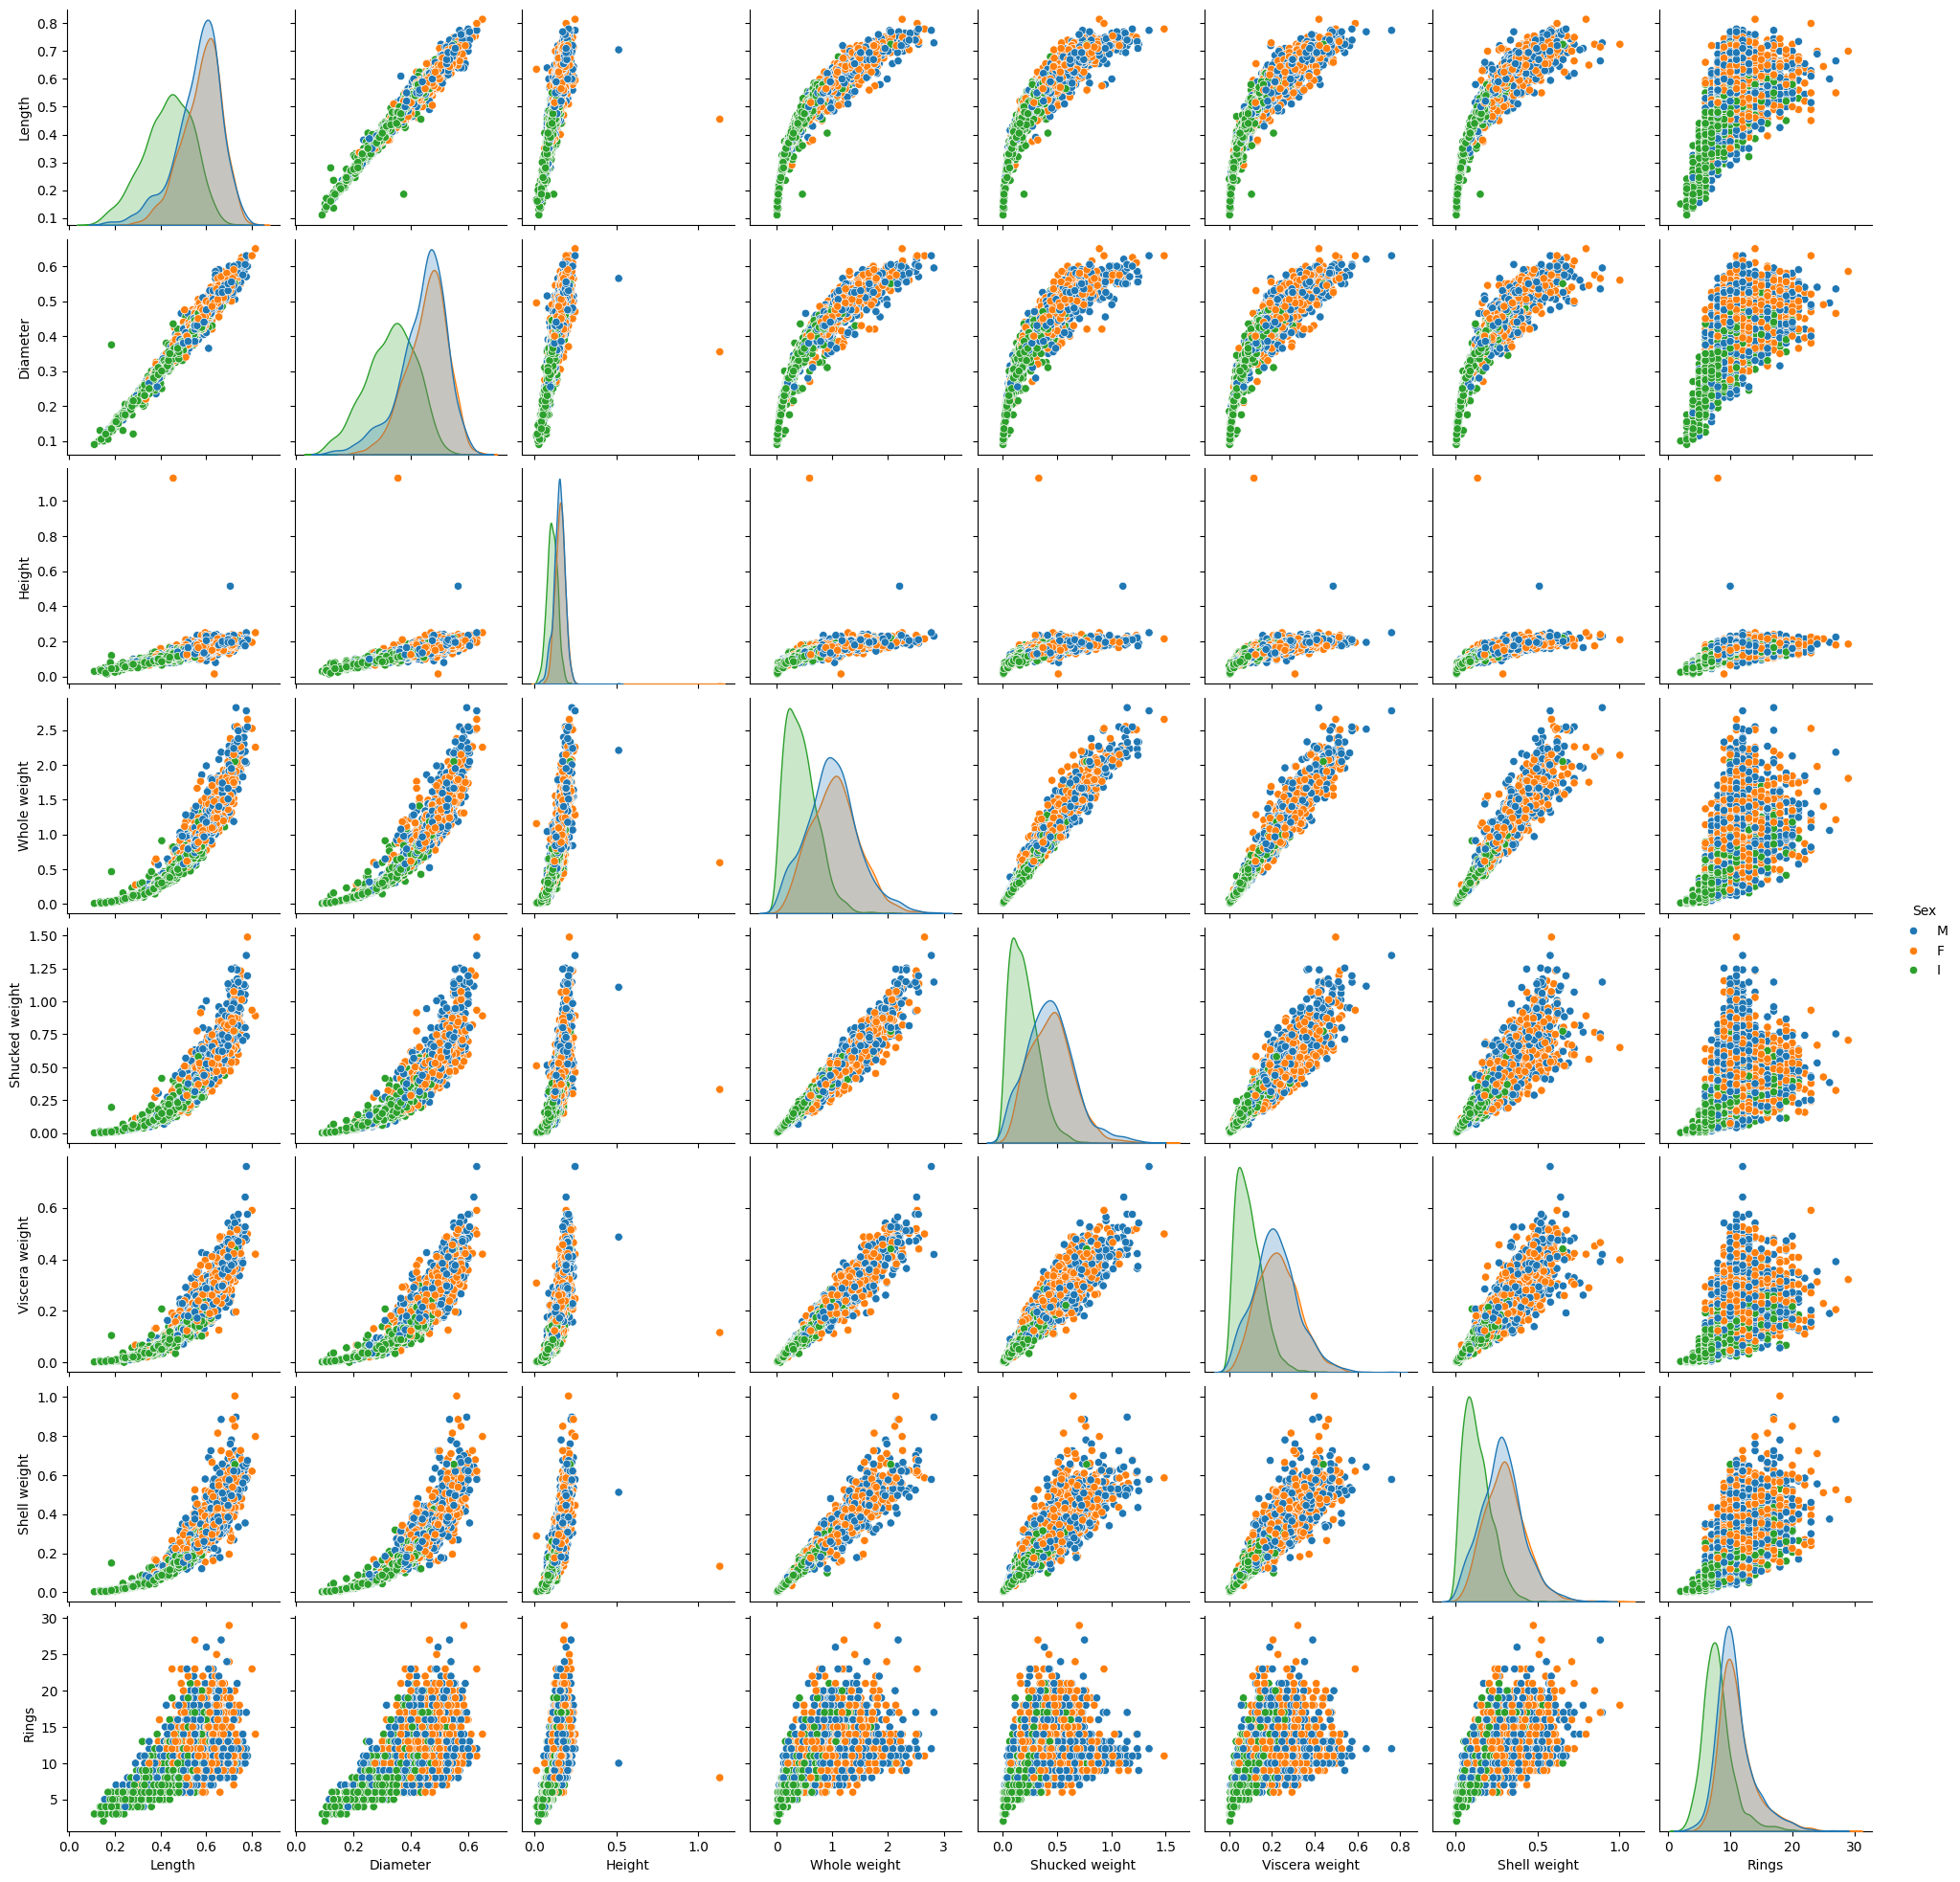

In [5]:
# 2)
sns.pairplot(abalone_df, hue="Sex")

<Axes: ylabel='Height'>

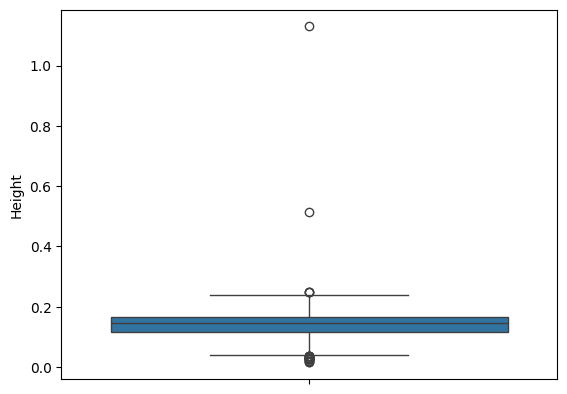

In [6]:
# 3)
sns.boxplot(abalone_df["Height"])

<Axes: xlabel='Height', ylabel='Count'>

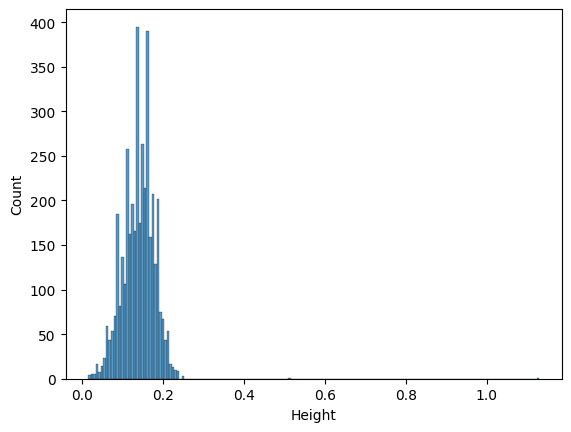

In [7]:
sns.histplot(abalone_df["Height"])

<Axes: ylabel='Whole weight'>

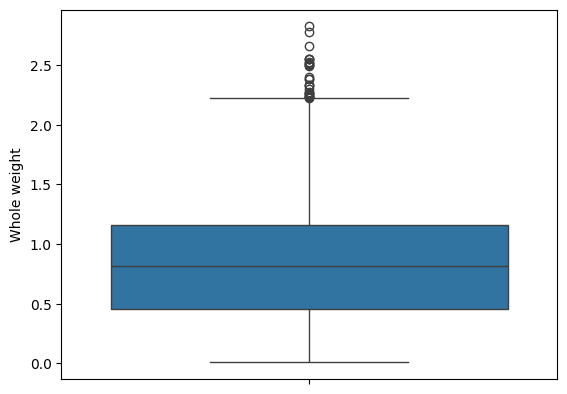

In [8]:
sns.boxplot(abalone_df["Whole weight"])

<Axes: xlabel='Whole weight', ylabel='Count'>

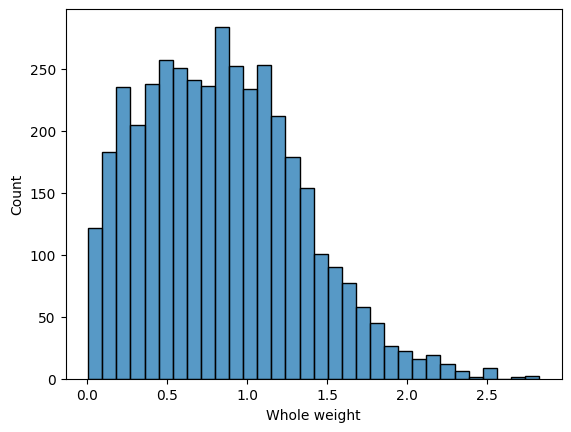

In [9]:
sns.histplot(abalone_df["Whole weight"])

<Axes: ylabel='Shell weight'>

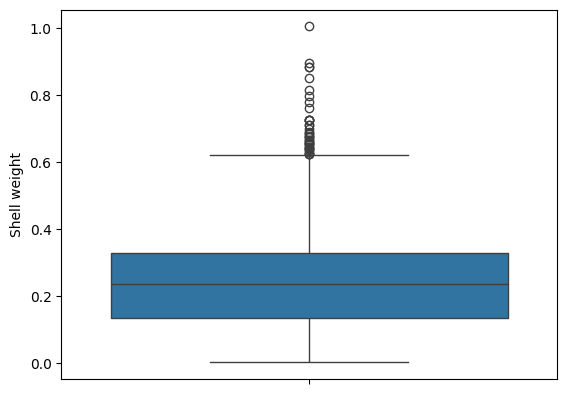

In [10]:
sns.boxplot(abalone_df["Shell weight"])

<Axes: xlabel='Shell weight', ylabel='Count'>

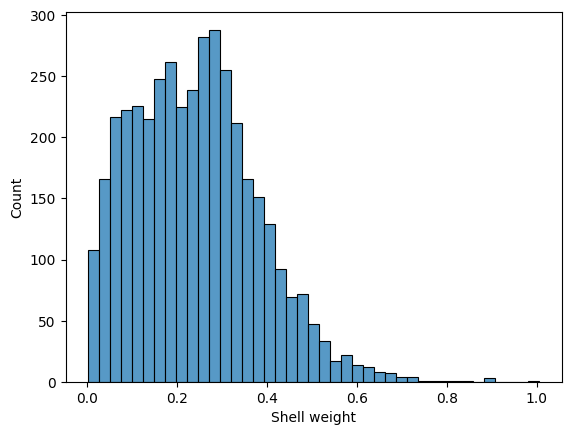

In [11]:
sns.histplot(abalone_df["Shell weight"])

<Axes: ylabel='Shucked weight'>

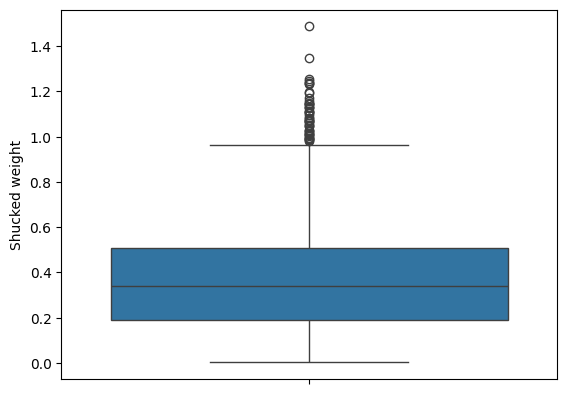

In [12]:
sns.boxplot(abalone_df["Shucked weight"])

<Axes: xlabel='Shucked weight', ylabel='Count'>

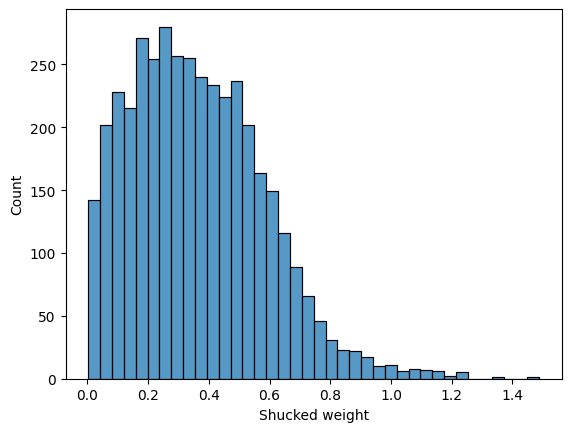

In [13]:
sns.histplot(abalone_df["Shucked weight"])

<Axes: ylabel='Viscera weight'>

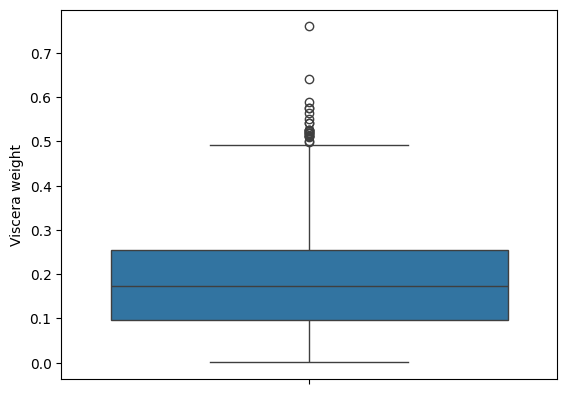

In [14]:
sns.boxplot(abalone_df["Viscera weight"])

<Axes: xlabel='Viscera weight', ylabel='Count'>

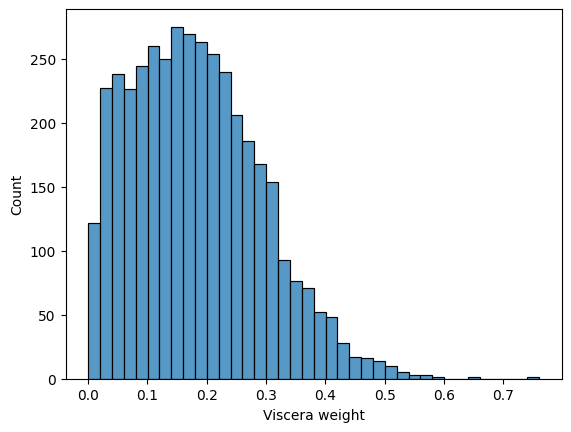

In [15]:
sns.histplot(abalone_df["Viscera weight"])

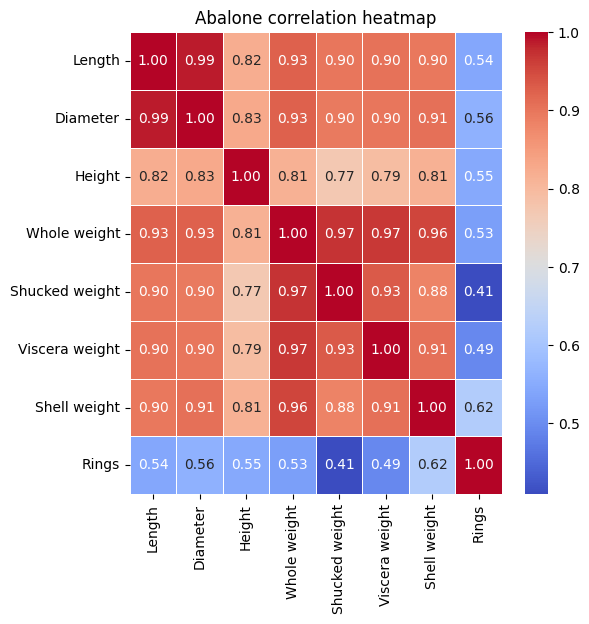

In [16]:
# 4)
abalone_num_data = abalone_df.select_dtypes("number")
corr_matrix = abalone_num_data.corr(method="pearson")

plt.figure(figsize=(6,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Abalone correlation heatmap")
plt.show()

In [17]:
# Zadanie 3

# 1)
X = abalone_df.drop(columns=["Rings"])
y = abalone_df["Rings"]

# 2)
one_hot_encoder = OneHotEncoder(sparse_output=False)
abalone_sex_encoded = one_hot_encoder.fit_transform(X[["Sex"]])
abalone_sex_encoded_df = pd.DataFrame(abalone_sex_encoded, columns=one_hot_encoder.get_feature_names_out())

X = X.drop(labels=["Sex"], axis=1)
X = X.reset_index(drop=True)
X = pd.concat([X, abalone_sex_encoded_df], axis=1)

# 3) 
sex_col_decoded = one_hot_encoder.inverse_transform(abalone_sex_encoded_df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=sex_col_decoded)

In [18]:
# 4)
f_amount_train = X_train["Sex_F"].value_counts() / len(X_train)
m_amount_train = X_train["Sex_M"].value_counts() / len(X_train)
i_amount_train = X_train["Sex_I"].value_counts() / len(X_train)
print(f"Train set data: \nshape: {X_train.shape} \nsex distribution across train set: \n- female: {f_amount_train}\n- male: {m_amount_train}\n- infant: {i_amount_train}\n")
print(X_train.info())

Train set data: 
shape: (3216, 10) 
sex distribution across train set: 
- female: Sex_F
0.0    0.681903
1.0    0.318097
Name: count, dtype: float64
- male: Sex_M
0.0    0.630286
1.0    0.369714
Name: count, dtype: float64
- infant: Sex_I
0.0    0.687811
1.0    0.312189
Name: count, dtype: float64

<class 'pandas.DataFrame'>
Index: 3216 entries, 3833 to 1762
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Length          3216 non-null   float64
 1   Diameter        3216 non-null   float64
 2   Height          3216 non-null   float64
 3   Whole weight    3216 non-null   float64
 4   Shucked weight  3216 non-null   float64
 5   Viscera weight  3216 non-null   float64
 6   Shell weight    3216 non-null   float64
 7   Sex_F           3216 non-null   float64
 8   Sex_I           3216 non-null   float64
 9   Sex_M           3216 non-null   float64
dtypes: float64(10)
memory usage: 276.4 KB
None


In [19]:
f_amount_test = X_test["Sex_F"].value_counts() / len(X_test)
m_amount_test = X_test["Sex_M"].value_counts() / len(X_test)
i_amount_test = X_test["Sex_I"].value_counts() / len(X_test)
print(f"Test set shape: {X_test.shape} \nsex distribution across test set: \n- female: {f_amount_test}\n- male: {m_amount_test}\n- infant: {i_amount_test}\n")
print(X_test.info())

Test set shape: (805, 10) 
sex distribution across test set: 
- female: Sex_F
0.0    0.681988
1.0    0.318012
Name: count, dtype: float64
- male: Sex_M
0.0    0.629814
1.0    0.370186
Name: count, dtype: float64
- infant: Sex_I
0.0    0.688199
1.0    0.311801
Name: count, dtype: float64

<class 'pandas.DataFrame'>
Index: 805 entries, 1248 to 3537
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Length          805 non-null    float64
 1   Diameter        805 non-null    float64
 2   Height          805 non-null    float64
 3   Whole weight    805 non-null    float64
 4   Shucked weight  805 non-null    float64
 5   Viscera weight  805 non-null    float64
 6   Shell weight    805 non-null    float64
 7   Sex_F           805 non-null    float64
 8   Sex_I           805 non-null    float64
 9   Sex_M           805 non-null    float64
dtypes: float64(10)
memory usage: 69.2 KB
None


In [20]:
# 5)
labels_to_skip = one_hot_encoder.get_feature_names_out()
cols_to_clip = [lst for lst in X_train.columns if lst not in labels_to_skip]

# Compute stds and means for train set only
stds = X_train[cols_to_clip].std(axis=0)
means = X_train[cols_to_clip].mean(axis=0)

X_train[cols_to_clip] = X_train[cols_to_clip].clip(
    lower=means - 3 * stds,
    upper=means + 3 * stds,
    axis=1
)
# Apply stds and means from train set to test set with 3sigma rule clipping
X_test[cols_to_clip] = X_test[cols_to_clip].clip(
    lower=means - 3 * stds,
    upper=means + 3 * stds,
    axis=1
)

In [21]:
# 6)
x_scaler = StandardScaler()
y_scaler = StandardScaler()

# convert to np array and make it two dimensional
X_train[cols_to_clip] = x_scaler.fit_transform(X_train[cols_to_clip])
y_train = y_train.values.reshape(-1, 1)
y_train = y_scaler.fit_transform(y_train)

X_test[cols_to_clip] = x_scaler.transform(X_test[cols_to_clip])
y_test = y_test.values.reshape(-1, 1)
y_test = y_scaler.transform(y_test)

2026-04-12 14:54:45.993526: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-12 14:54:45.993554: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-04-12 14:54:45.993559: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1775998485.993571 4011987 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1775998485.993587 4011987 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 953 (3.72 KB)

 Trainable params: 953 (3.72 KB)

 Non-trainable params: 0 (0.00 B)

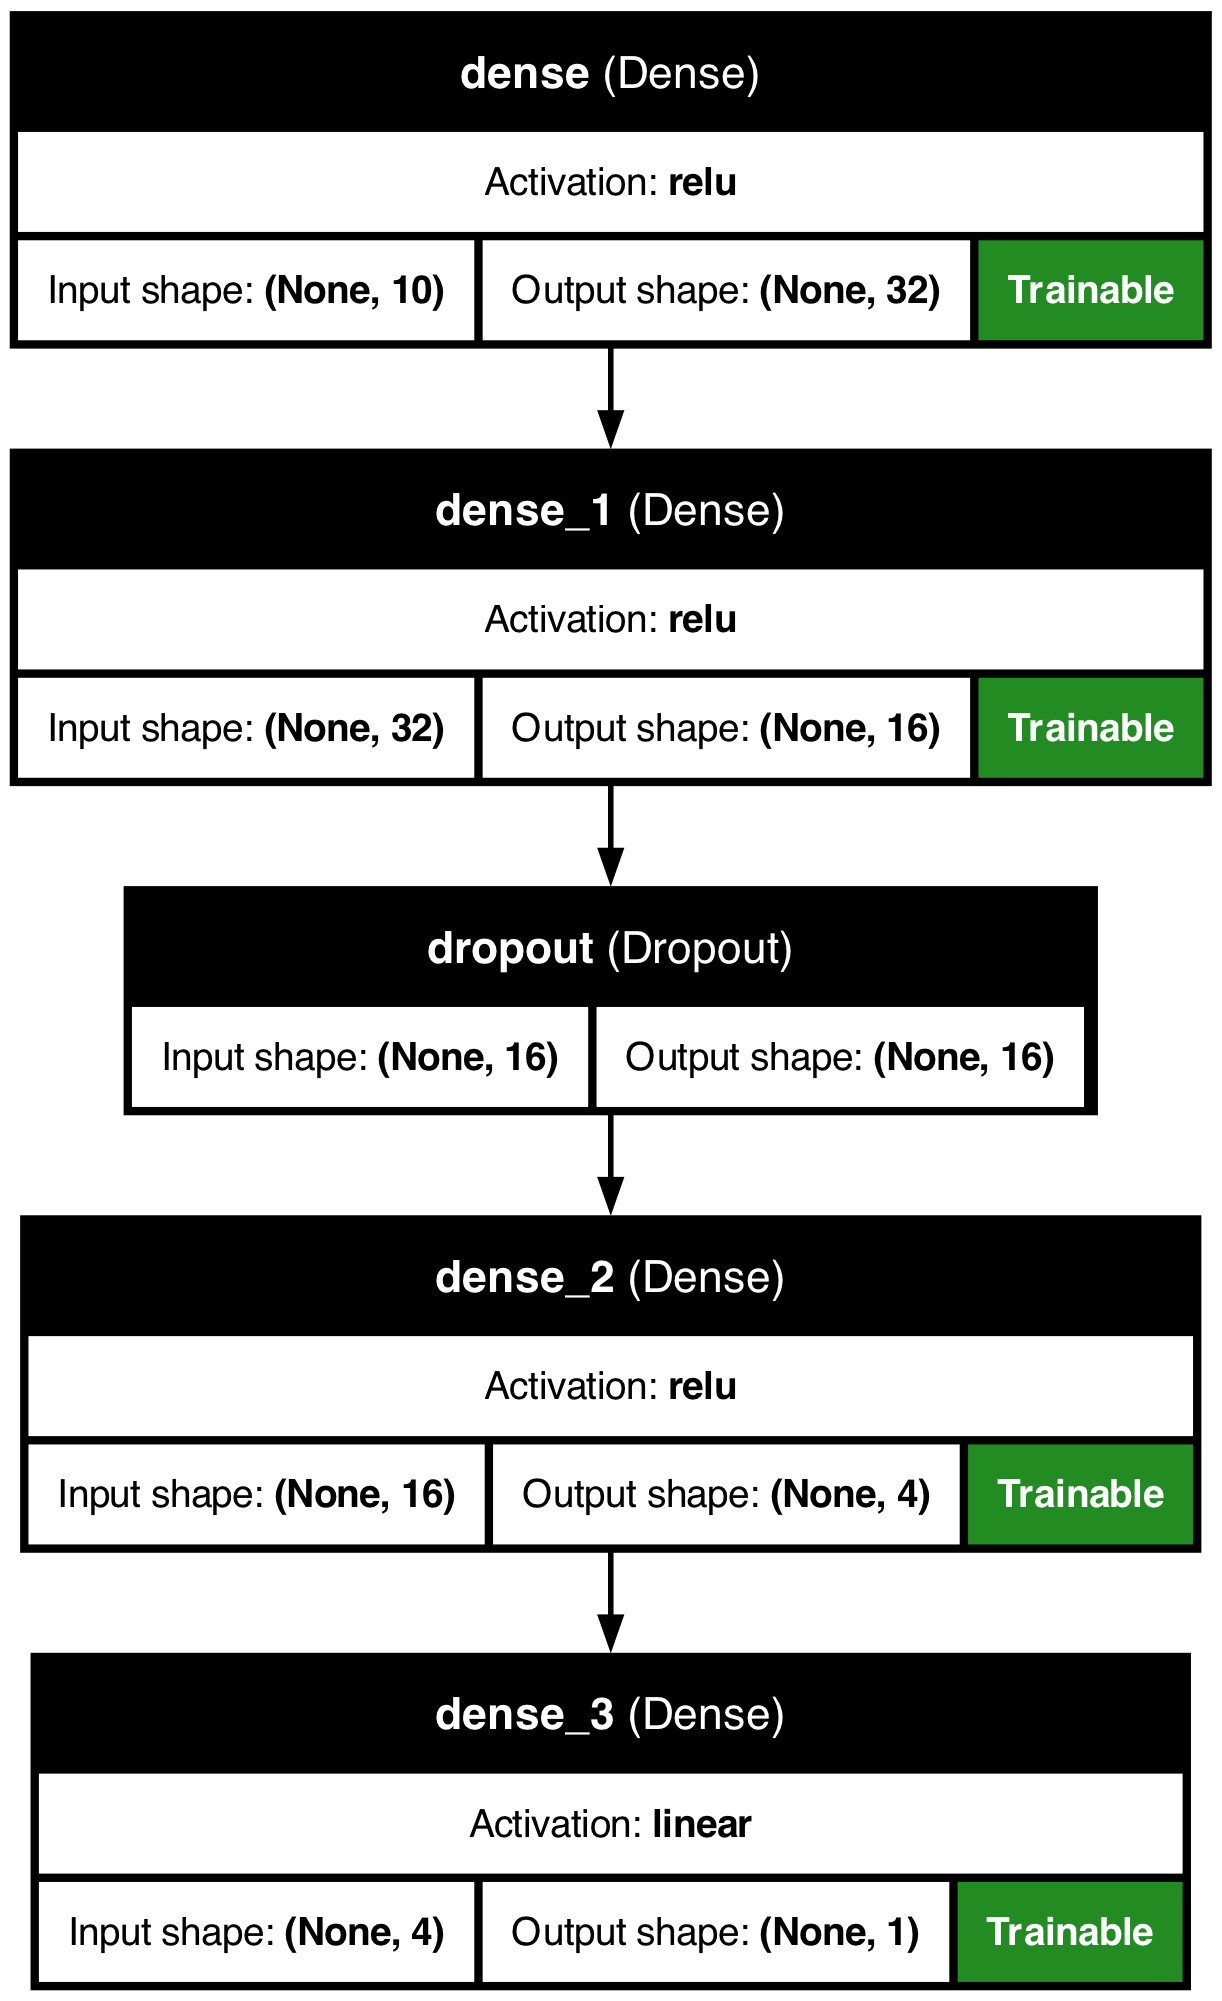

In [22]:
# Zadanie 4
# 1)
model = keras.models.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dropout(rate=0.1),
    keras.layers.Dense(4, activation="relu"),
    keras.layers.Dense(1, activation="linear"),
])

# 2)
model.summary()
keras.utils.plot_model(model, "abalone_ann.png", show_shapes=True, show_layer_names=True, show_layer_activations=True, show_trainable=True)
Image(filename="abalone_ann.png", width=400)

In [23]:
# 3)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-4),
    loss="mean_squared_error",
    metrics=["r2_score"]
)

In [24]:
# 4)
root_logdir = os.path.join(os.curdir, "my_logs")
logdir = os.path.join(root_logdir, "run_{}".format(time.time()))

%load_ext tensorboard
%tensorboard --logdir {root_logdir}

history = model.fit(
    X_train, 
    y_train, 
    epochs=20, 
    validation_data=(X_test, y_test), 
    callbacks=[
        keras.callbacks.TensorBoard(log_dir=logdir),
        keras.callbacks.EarlyStopping(monitor="val_r2_score", patience=5, mode="max", restore_best_weights=True),
        keras.callbacks.ModelCheckpoint("abalone_ann.keras", save_best_only=True)
    ]
)


Reusing TensorBoard on port 6006 (pid 77450), started 2 days, 14:19:44 ago. (Use '!kill 77450' to kill it.)

Epoch 1/20


2026-04-12 14:54:46.498084: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.0338 - r2_score: -0.0338 - val_loss: 0.7492 - val_r2_score: 0.2471
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.9080 - r2_score: 0.0920 - val_loss: 0.6906 - val_r2_score: 0.3060
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8378 - r2_score: 0.1622 - val_loss: 0.6431 - val_r2_score: 0.3537
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8217 - r2_score: 0.1783 - val_loss: 0.6015 - val_r2_score: 0.3956
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.7735 - r2_score: 0.2265 - val_loss: 0.5749 - val_r2_score: 0.4223
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.7650 - r2_score: 0.2350 - val_loss: 0.5501 - val_r2_score: 0.4472
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.7600 - r2_score: 0.2400 - val_loss: 0.5330 - val_r2_score: 0.4643
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.7142 - r2_score: 0.2858 - val_loss: 0.5196 - val_r2_

<Axes: xlabel='Epochs', ylabel='Score value'>

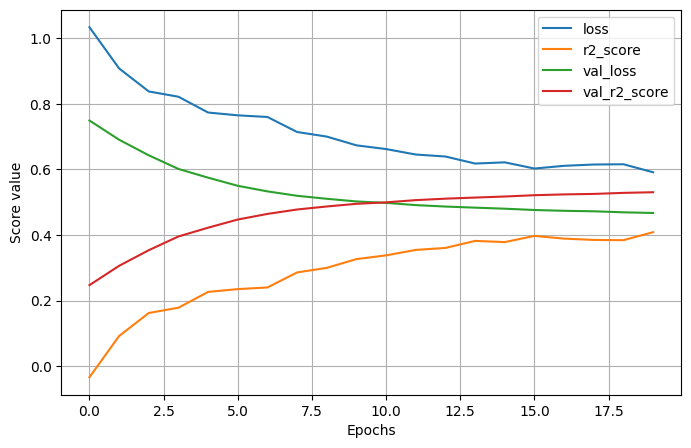

In [25]:
# 5)
pd.DataFrame(history.history).plot(figsize=(8, 5), grid=True, xlabel="Epochs", ylabel="Score value")

# Note:
# learning_rate=1e-4 / epochs 20
# Models seems to underfits the data. The validation R2 score is around 0.48 so it means the model can explain around 48% of the variance of the dataset - model is not learning well the training data.
# The loss being lower in validation set is expected due to dropout in model architecture. 
# Applying more epochs to training seems very unstable, early stopping occurs rather fast(around 30-40th epoch usually).


101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 960us/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MSE for model predictions, train set: 5.531716417910448, test set: 5.193788819875777
R2 for model predictions, train set: 0.46746295261570714, test set: 0.4975430298213299


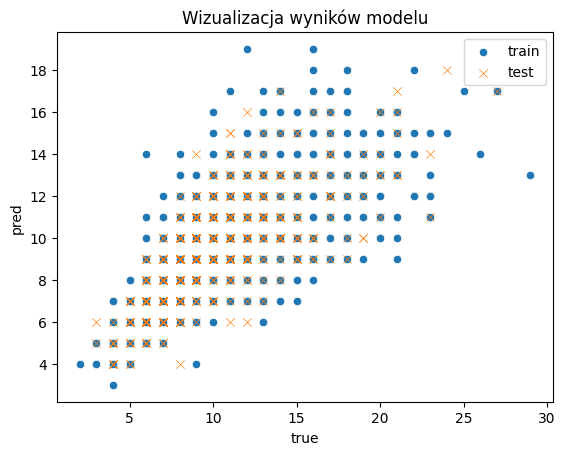

In [26]:
# 6)
# inversing labels
y_train_inv_transformed =   y_scaler.inverse_transform(y_train).astype(dtype="int64")
y_test_inv_transformed = y_scaler.inverse_transform(y_test).astype(dtype="int64")

y_train_preds = model.predict(X_train)
y_test_preds = model.predict(X_test)

# inversing predictions
y_train_preds_inv_transformed = y_scaler.inverse_transform(y_train_preds).astype(dtype="int64")
y_test_preds_inv_transformed = y_scaler.inverse_transform(y_test_preds).astype(dtype="int64")

# plotting labels and predictions for train set
pred_plot = sns.scatterplot(x=y_train_inv_transformed.flatten(), y=y_train_preds_inv_transformed.flatten(), label="train")
pred_plot = sns.scatterplot(x=y_test_inv_transformed.flatten(), y=y_test_preds_inv_transformed.flatten(), label="test", marker="x")
pred_plot.set_xlabel("true")
pred_plot.set_ylabel("pred")
pred_plot.set_title("Wizualizacja wyników modelu")

# compute MSE and R2 for train and test sets
train_preds_mse = mean_squared_error(y_true=y_train_inv_transformed, y_pred=y_train_preds_inv_transformed)
train_preds_r2 = r2_score(y_true=y_train_inv_transformed, y_pred=y_train_preds_inv_transformed)

test_preds_mse = mean_squared_error(y_true=y_test_inv_transformed, y_pred=y_test_preds_inv_transformed)
test_preds_r2 = r2_score(y_true=y_test_inv_transformed, y_pred=y_test_preds_inv_transformed)

print(f"MSE for model predictions, train set: {train_preds_mse}, test set: {test_preds_mse}")
print(f"R2 for model predictions, train set: {train_preds_r2}, test set: {test_preds_r2}")

# 7) 
# At this point model is not handling predictions well: MSE both train and test set being around 5,5 means that without square root it's 2,34. Model is on average 2.34 rings off the actual prediction.
# Having whole dataset ring mean being ~ 9.9 it's actually high error margin and model should be improved.
# R2 score train set ~ 0.46 and test set ~ 0.47 means that model poorly accounts only around 46/47% of the variance of datasets - model captures less than half of the patterns in the data.

In [27]:
# Zadanie 5
def build_model(hp: HyperParameters):
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(X_train.shape[1],)))
    model.add(keras.layers.Dense(30, activation="relu"))
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=5, step=1)
    n_neurons = hp.Int("n_neurons", min_value=5, max_value=30, step=5)

    for _ in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation=hp.Choice("activation", ["relu", "tanh"]),))

    if hp.Boolean("dropout"):
        model.add(keras.layers.Dropout(rate=hp.Choice("rate", [0.1, 0.15, 0.2, 0.25])))
    model.add(keras.layers.Dense(1, activation="linear"))
    
    lr = hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4, 1e-5, 3e-4, 3e-3])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mean_squared_error",
        metrics=["r2_score"]
    )
    return model

objective = Objective("val_r2_score", direction="max")
tuner = RandomSearch(
    build_model, 
    objective=objective,
    max_trials=5,
    executions_per_trial=3,
    directory='keras_tuner',
    project_name='abalone',
)
tuner.search(
    X_train, 
    y_train, 
    epochs=50,
    validation_data=(X_test, y_test), 
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_r2_score", patience=5, mode="max", restore_best_weights=True)
        ]
    )

best_model = tuner.get_best_models(num_models=1)[0]
print(best_model.evaluate(X_test, y_test))

Trial 5 Complete [00h 01m 15s]
val_r2_score: 0.6060613791147867

Best val_r2_score So Far: 0.6127388079961141
Total elapsed time: 00h 03m 41s
 1/26 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - loss: 0.2201 - r2_score: 0.5633

/Users/jancewicz/Repos/PJATK/PJATK---Artificial-Intelligence-Postgraduate-Studies-/keras/venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3842 - r2_score: 0.6140
[0.3841581642627716, 0.6139578223228455]
